## Data Visualization Intro: Using Pandas, Seaborn & Matplotlib

- This is a quick intro on visualizing data and cleaning data based on a dataset called Titanic Train. 

- Data will be extracted and presented into a analytical form for interpretation!


### ~ First we will install and import all necessary modules that will help us visualize data.

In [5]:
pip install pandas -q #-q supresses the installation output

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
#Now we will add our file to pandas to start working. (Make sure your dataset is in the same folder as your working file)

t_t=pd.read_csv ('titanic_train.csv')

#calling 't_t' Automatically prints first and last 5 records of the dataset 
#Alternative can be using the .head(# of begining records) or .tail(# of final records)
#Ex: t_t.head(5)

t_t

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### ~ Lets get to know our column labels!


In [3]:
t_t.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### ~ Lets now get a statistical summary of our data! (This only works for numeric values)


In [4]:
t_t.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### ~ We will now take a look at transfroming the data to graphs/diagrams with the help of seaborn.

### ~ seaborn.countplot(data=None, *, x=None, y=None, hue=None, order=None, hue_order=None, orient=None, color=None, palette=None, saturation=0.75, fill=True, hue_norm=None, stat='count', width=0.8, dodge='auto', gap=0, log_scale=None, native_scale=False, formatter=None, legend='auto', ax=None, **kwargs)

<Axes: xlabel='Pclass', ylabel='count'>

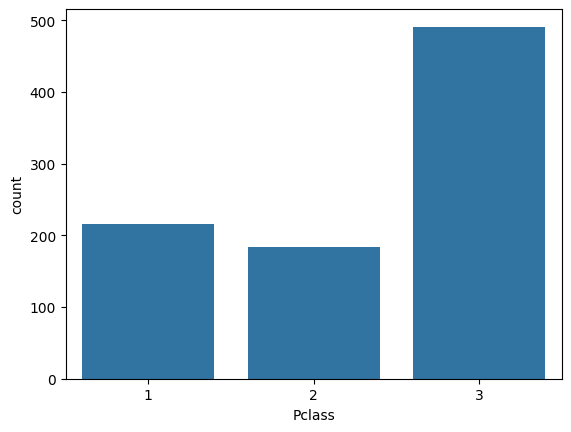

In [ ]:
sns.countplot(data = t_t, x="Pclass")

<Axes: xlabel='Survived', ylabel='count'>

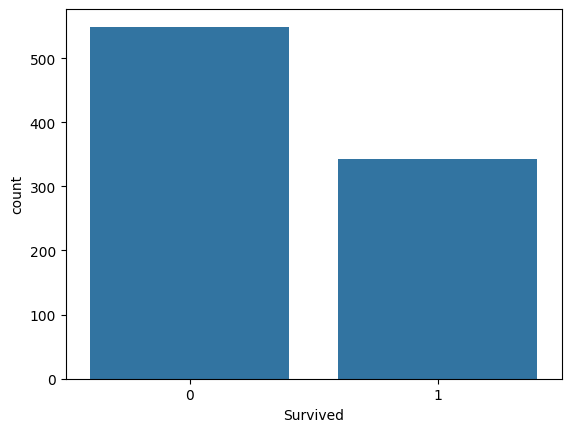

In [25]:
sns.countplot(data = t_t, x='Survived')

### ~ Now see what happens if you try countplot with coloumns like "Age" or "Fare"


<Axes: xlabel='Age', ylabel='count'>

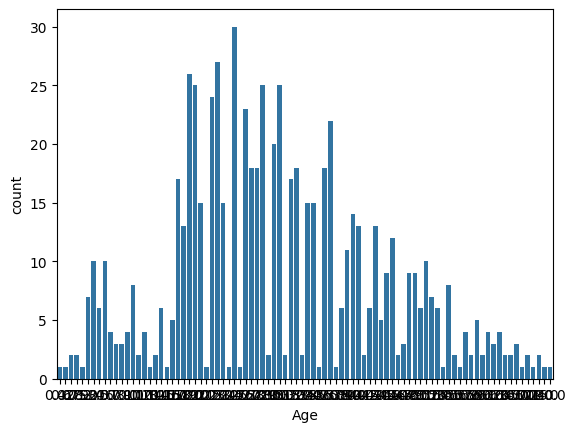

In [ ]:
sns.countplot(data = t_t, x="Age")

### ~ The x-axis becomes very messy  because you're plotting many unique Age values as categorical bars in a countplot, which is not ideal for continuous data like age. sns.countplot() is better suited for discrete categorical variables 


### ~ Moving forward I will demonstrate using countplot to showcase a relation between survival ratio per Pclass
### ~ 1 = Survived   |    0 = Not Survived

<Axes: xlabel='Pclass', ylabel='count'>

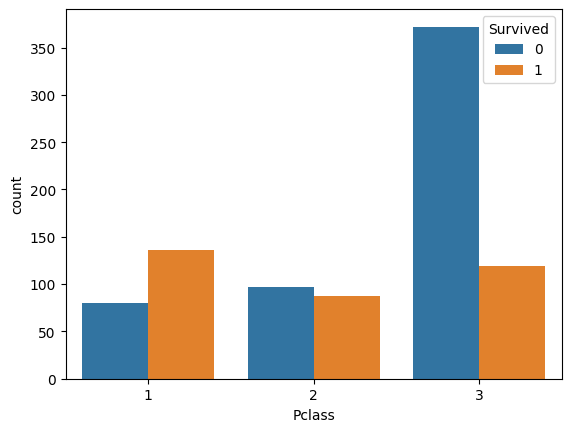

In [22]:
sns.countplot(data = t_t, x="Pclass", hue="Survived")

### ~ We shall now filter data based on people of the Male gender who survived and print out 'Name', 'Sex', 'Age', and 'Survived'

- loc[] gets rows (or columns) with particular labels from the index.
- "NaN" stands for "Not a Number", and it represents missing or undefined values in a dataset.

In [35]:
malesurvived = t_t.loc [(t_t.Sex=="male") & (t_t.Survived==1), ['Name','Sex','Age', "Survived"]]
malesurvived

,Name,Sex,Age,Survived
17,"Williams, Mr. Charles Eugene",male,NaN,1
21,"Beesley, Mr. Lawrence",male,34.0,1
23,"Sloper, Mr. William Thompson",male,28.0,1
36,"Mamee, Mr. Hanna",male,NaN,1
55,"Woolner, Mr. Hugh",male,NaN,1
...,...,...,...,...
838,"Chip, Mr. Chang",male,32.0,1
839,"Marechal, Mr. Pierre",male,NaN,1
857,"Daly, Mr. Peter Denis",male,51.0,1
869,"Johnson, Master. Harold Theodor",male,4.0,1


### ~ Next we will see a distribution of age for males who survived
### ~ Colors to use for the different levels of the hue variable
### ~ The order in countplot variables does not matter

<Axes: xlabel='Survived', ylabel='count'>

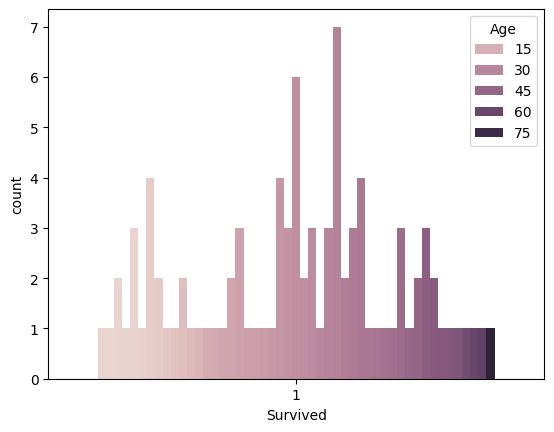

In [36]:
sns.countplot(data = malesurvived, x='Survived', hue = 'Age')

### ~ To get a quick check on the number of unique values in each column you can do: .value_counts(LABEL)


In [47]:
t_t.value_counts("Survived"), t_t.value_counts("Sex")

(Survived
 0    549
 1    342
 Name: count, dtype: int64,
 Sex
 male      577
 female    314
 Name: count, dtype: int64)

### ~ Unlike countplot if we want to visualize more continous data like the 'Age' column then we need to use sns.displot()
### ~ sns.displot() uses binned x-axis to group values instead of having many unique values

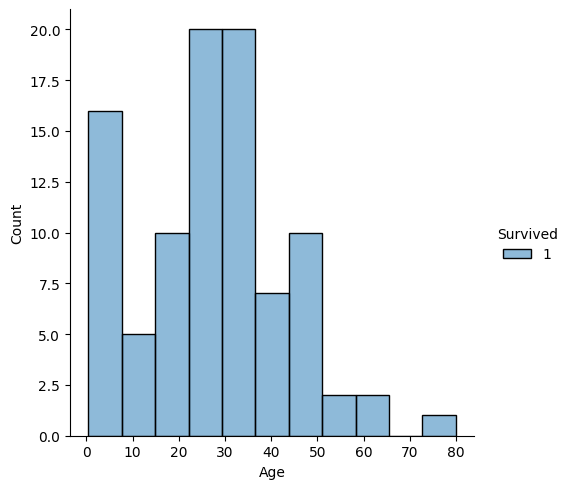

In [37]:
sns.displot(data = malesurvived, x='Age', hue = 'Survived')

### ~ Data can be showcased through histograms as well like the following:

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Survived'}>]], dtype=object)

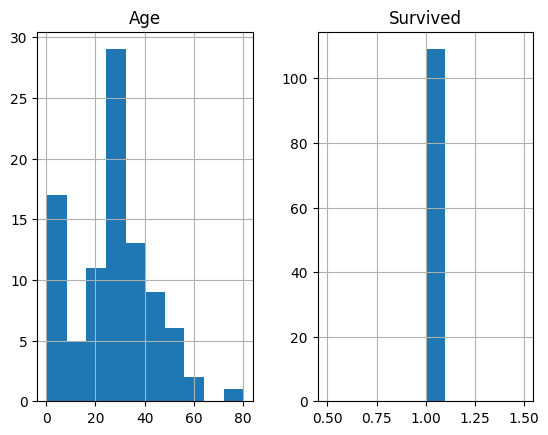

In [48]:
malesurvived.hist()

### ~ We can also call .hist() for all numeric columns

array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

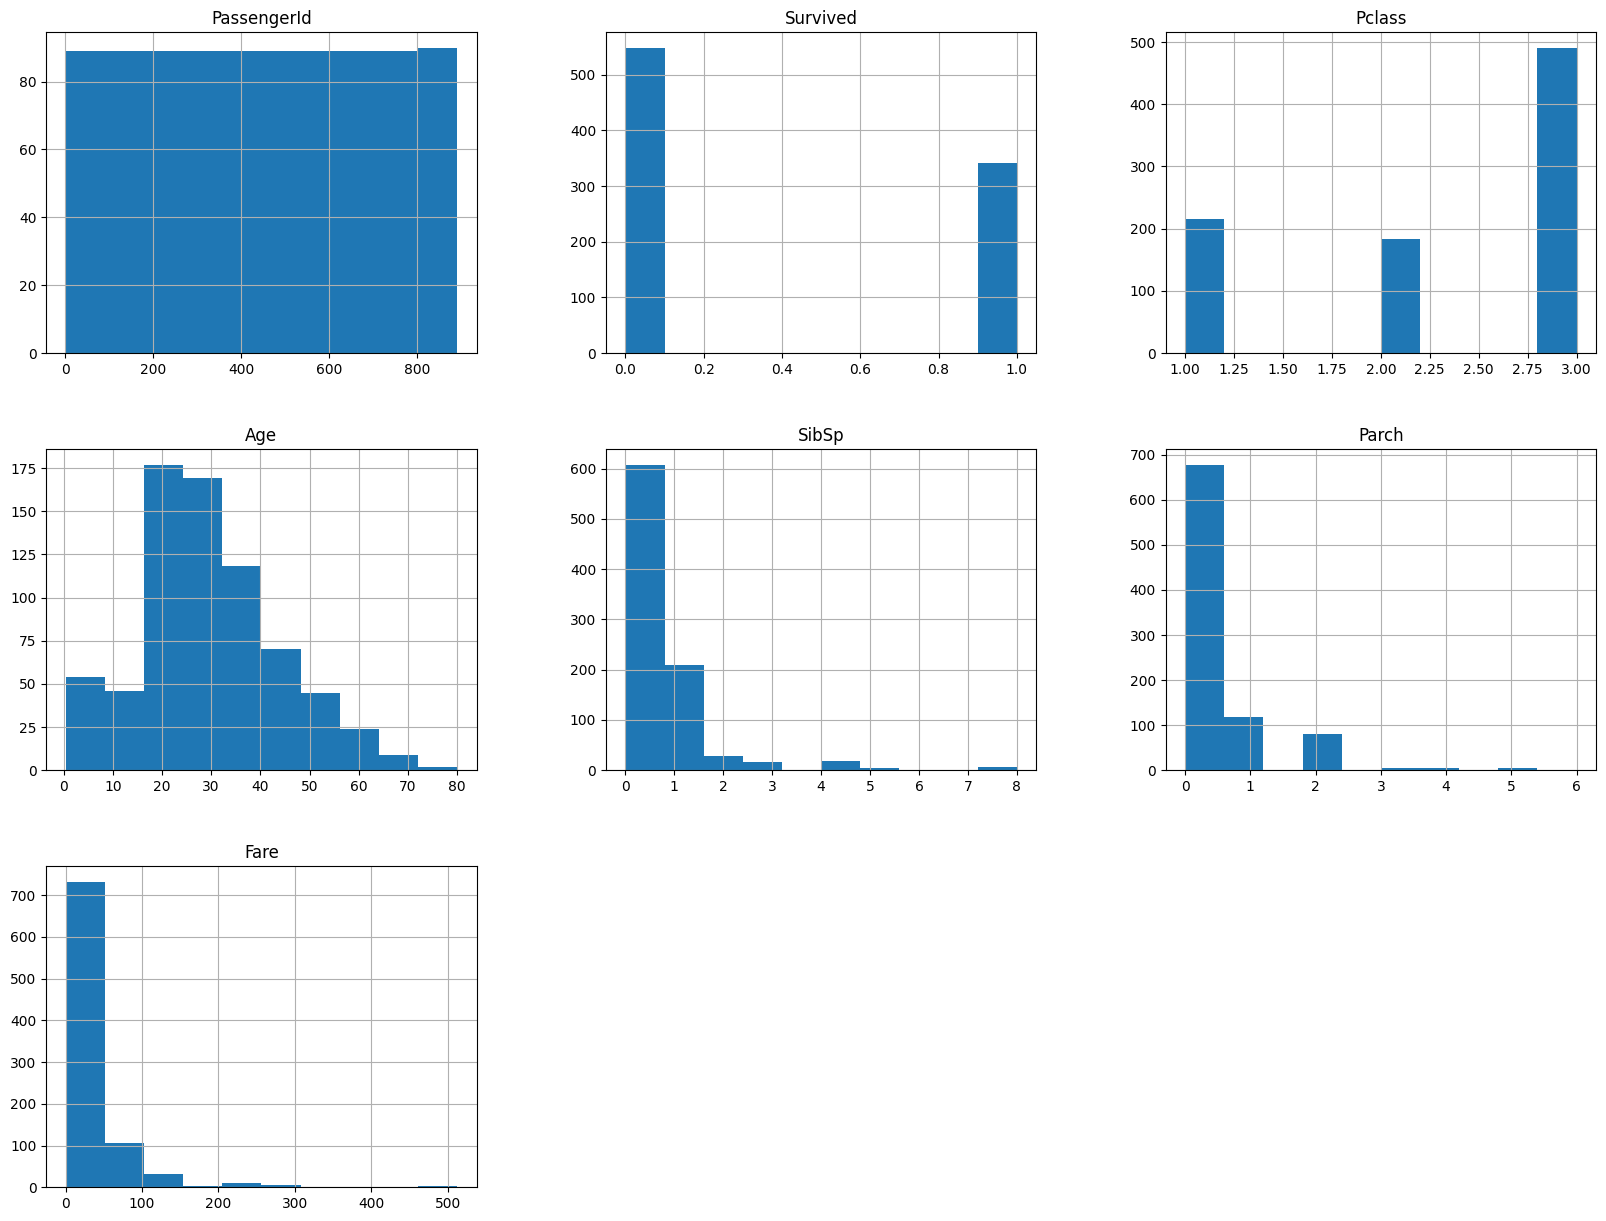

In [50]:
t_t.hist(bins = 10, figsize = (20, 15))

### ~ bins=10: Divides the data range into 10 intervals (bins) per histogram. 
- Fewer bins = broader categories; more bins = finer detail.
### ~ figsize=(20, 15): Sets the overall figure size in inches (width=20, height=15), making it easier to read.